In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import time
import matplotlib.pyplot as plt
from scipy.signal import detrend
import scipy.stats as stats
from scipy.stats import bootstrap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import geopandas as gpd
import seaborn as sns
from math import radians, cos
import rasterio
from matplotlib.colors import LinearSegmentedColormap
from rasterio.transform import from_origin
import xskillscore as xs
import numpy.ma as ma
import os
from statsmodels.stats.multitest import multipletests
import pickle

In [2]:
file_path = '/home/madhulika.gurazada/paper2/Data/Nino3.4_OG_SST1.xlsx'

nino34 = pd.read_excel(file_path)

nino34_1900_2024 = nino34[(nino34['Year'] >= 1900) & (nino34['Year'] <= 2024)]

def select_seasons(data):
    # Create DJF (December, January, February) within the function
    djf_data = pd.DataFrame(columns=['Year', 'Dec', 'Jan', 'Feb'])
    djf_data['Year'] = data['Year'] 
    djf_data['Dec'] = data['Dec']
    djf_data['Jan'] = data['Jan'].shift(-1)
    djf_data['Feb'] = data['Feb'].shift(-1)
    
    return djf_data

# Assuming you have already read the data into 'nino34_1900_2022'
djf_data = select_seasons(nino34_1900_2024)

# Define the columns for each season
seasonal_columns = {
    'DJF': ['Dec', 'Jan', 'Feb']
}

# Create a dictionary to hold the DataFrames
seasonal_data = {
    'DJF': djf_data
}

climatology_start_year = 1991
climatology_end_year = 2020

# Calculate seasonal means for each DataFrame
for season, columns in seasonal_columns.items():
    data = seasonal_data[season]
    data[f'{season}_Mean'] = data[columns].mean(axis=1)
    # Filter the data for the climatology years
    climatology_data = data[(data['Year'] >= climatology_start_year) & (data['Year'] <= climatology_end_year)]
    climatology_mean = climatology_data[f'{season}_Mean'].mean()
    climatology_std = climatology_data[f'{season}_Mean'].std()
    # Calculate Nino anomalies
    data[f'Nino_{season}_Anomaly'] = (data[f'{season}_Mean'] - climatology_mean)/climatology_std
    # Classify as El Niño, La Niña, or Neutral
    data[f'Nino_{season}_Classification'] = np.where(data[f'Nino_{season}_Anomaly'] > 0.5, 'El Niño',
                                                     np.where(data[f'Nino_{season}_Anomaly'] < -0.5, 'La Niña', 'Neutral'))
    
el_nino_years = {}
la_nina_years = {}
neutral_years = {}

for season in seasonal_columns.keys():
    data = seasonal_data[season]
    # Extract the years for each classification and filter for years between 1901 and 2024
    el_nino_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'El Niño')]['Year'].tolist()
    la_nina_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'La Niña')]['Year'].tolist()
    neutral_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'Neutral')]['Year'].tolist()

el_nino_years_1 = [year + 1 for year in el_nino_years['DJF']]
la_nina_years_1 = [year + 1 for year in la_nina_years['DJF']]
neutral_years_1 = [year + 1 for year in neutral_years['DJF']]

In [3]:
print(el_nino_years)
print(la_nina_years)
print(neutral_years)

{'DJF': [1902, 1904, 1905, 1911, 1913, 1914, 1918, 1923, 1925, 1930, 1939, 1940, 1941, 1957, 1963, 1965, 1968, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009, 2014, 2015, 2018, 2019, 2023]}
{'DJF': [1903, 1908, 1909, 1910, 1916, 1917, 1922, 1924, 1933, 1938, 1942, 1949, 1950, 1954, 1955, 1964, 1967, 1970, 1971, 1973, 1975, 1983, 1984, 1985, 1988, 1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2017, 2020, 2021, 2022, 2024]}
{'DJF': [1901, 1906, 1907, 1912, 1915, 1919, 1920, 1921, 1926, 1927, 1928, 1929, 1931, 1932, 1934, 1935, 1936, 1937, 1943, 1944, 1945, 1946, 1947, 1948, 1951, 1952, 1953, 1956, 1958, 1959, 1960, 1961, 1962, 1966, 1969, 1974, 1978, 1979, 1980, 1981, 1989, 1990, 1992, 1993, 1996, 2001, 2003, 2004, 2012, 2013, 2016]}


In [4]:
cru_pre = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/cru_ts4.09.1901.2024.pre.dat.nc')
cru_pre.info()  

# Define the seasons based on months
mam_months = [3, 4, 5]  # March, April, May
jja_months = [6, 7, 8]  # June, July, August
son_months = [9, 10, 11]  # September, October, November
djf = []  # December, January, February

# Select the seasons based on months
pre_mam_data = cru_pre.sel(time=cru_pre['time.month'].isin(mam_months))
pre_jja_data = cru_pre.sel(time=cru_pre['time.month'].isin(jja_months))
pre_son_data = cru_pre.sel(time=cru_pre['time.month'].isin(son_months))

pre_mam_data['year'] = pre_mam_data['time'].dt.year
pre_mam1_data_year = pre_mam_data['year'] + 1
pre_mam1_data_year = pre_mam1_data_year[pre_mam1_data_year != 2025]
pre_mam1_data = pre_mam_data.sel(time=pre_mam_data['time.year'].isin(pre_mam1_data_year))

pre_jja_data['year'] = pre_jja_data['time'].dt.year
pre_jja1_data_year = pre_jja_data['year'] + 1
pre_jja1_data_year = pre_jja1_data_year[pre_jja1_data_year != 2025]
pre_jja1_data = pre_jja_data.sel(time=pre_jja_data['time.year'].isin(pre_jja1_data_year))

pre_son_data['year'] = pre_son_data['time'].dt.year
pre_son1_data_year = pre_son_data['year'] + 1
pre_son1_data_year = pre_son1_data_year[pre_son1_data_year != 2025]
pre_son1_data = pre_son_data.sel(time=pre_son_data['time.year'].isin(pre_son1_data_year))

# Iterate over the years from 1901 to 2020
for year in range(1901, 2024):
    # Select December data for the current year
    dec = cru_pre.sel(time=(cru_pre['time.month'] == 12) & (cru_pre['time.year'] == year))
    djf.append(dec)
    
    # Select January data for the next year and assign 'year' as the next year
    jan = cru_pre.sel(time=(cru_pre['time.month'] == 1) & (cru_pre['time.year'] == year + 1))
    djf.append(jan)
    
    # Select February data for the next year and assign 'year' as the next year
    feb = cru_pre.sel(time=(cru_pre['time.month'] == 2) & (cru_pre['time.year'] == year + 1))
    djf.append(feb)

# Concatenate the list of data arrays along the 'time' dimension to create the DJF dataset
pre_djf_data = xr.concat(djf, dim='time')

def calculate_yearly_mean(data):
    # Calculate the yearly mean
    yearly_mean = data.groupby('time.year').mean(dim='time')
    return yearly_mean

# Calculate yearly means for each season
# pre_mam_mean_yearly = calculate_yearly_mean(pre_mam_data)
pre_jja_mean_yearly = calculate_yearly_mean(pre_jja_data)
pre_son_mean_yearly = calculate_yearly_mean(pre_son_data)
pre_djf_mean_yearly = calculate_yearly_mean(pre_djf_data)
pre_mam1_mean_yearly = calculate_yearly_mean(pre_mam1_data)
pre_jja1_mean_yearly = calculate_yearly_mean(pre_jja1_data)
pre_son1_mean_yearly = calculate_yearly_mean(pre_son1_data)

def plot_precipitation_time_series(dataset, season):
    # Calculate the mean over the spatial dimensions (latitude and longitude)
    pre_median = dataset['pre'].median(dim=['lat', 'lon'])
    
    # Extract the years coordinate
    years = dataset['year']
    
    # Plotting the time series line plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, pre_median, marker='o', linestyle='-')
    plt.title(f'Precipitation ({season.upper()})')
    plt.xlabel('Year')
    plt.ylabel('Precipitation (mm)')
    plt.grid(True)
    plt.show()
    
# Function to compute mean, detrend and plot the data
def compute_and_plot_detrend(dataarray, season_name):
    # Compute the mean of 'pre' over 'lat' and 'lon' dimensions
    pre_median = dataarray['pre'].median(dim=['lat', 'lon'])
    
    # Detrend the time series
    detrended_pre_median = detrend(pre_median, type='linear')

    # Create a new DataArray for the detrended data
    detrended_pre_median_da = xr.DataArray(
        detrended_pre_median, 
        dims=['year'], 
        coords={'year': pre_median['year']}
    )

    # Plot the original and detrended data
    plt.figure(figsize=(10, 6))
    plt.plot(pre_median['year'], detrended_pre_median_da, label='Linear Detrend')
    plt.xlabel('Year')
    plt.ylabel('Precipitation')
    plt.title(f'Detrended Median Yearly Precipitation ({season_name})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define El Niño years for the composite maps
el_nino_years_djf = el_nino_years['DJF']
el_nino_years_1 = [year + 1 for year in el_nino_years_djf]

# Create composite maps for El Niño years
# pre_el_nino_composite_mam = pre_mam_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_jja = pre_jja_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_son = pre_son_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_djf = pre_djf_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_mam1 = pre_mam1_mean_yearly.sel(year=el_nino_years_1)
pre_el_nino_composite_jja1 = pre_jja1_mean_yearly.sel(year=el_nino_years_1)
pre_el_nino_composite_son1 = pre_son1_mean_yearly.sel(year=el_nino_years_1)

# Calculate the means of the precipitation variable
# pre_mam_el_nino = pre_el_nino_composite_mam.mean(dim='year')['pre']
pre_jja_el_nino = pre_el_nino_composite_jja.mean(dim='year')['pre']
pre_son_el_nino = pre_el_nino_composite_son.mean(dim='year')['pre']
pre_djf_el_nino = pre_el_nino_composite_djf.mean(dim='year')['pre']
pre_mam1_el_nino = pre_el_nino_composite_mam1.mean(dim='year')['pre']
pre_jja1_el_nino = pre_el_nino_composite_jja1.mean(dim='year')['pre']
pre_son1_el_nino = pre_el_nino_composite_son1.mean(dim='year')['pre']

la_nina_years_djf = la_nina_years['DJF']
la_nina_years_1 = [year + 1 for year in la_nina_years_djf]
la_nina_years_1 = la_nina_years_1[:-1]

# pre_la_nina_composite_mam = pre_mam_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_jja = pre_jja_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_son = pre_son_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_djf = pre_djf_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_mam1 = pre_mam1_mean_yearly.sel(year=la_nina_years_1)
pre_la_nina_composite_jja1 = pre_jja1_mean_yearly.sel(year=la_nina_years_1)
pre_la_nina_composite_son1 = pre_son1_mean_yearly.sel(year=la_nina_years_1)

# pre_mam_la_nina = pre_la_nina_composite_mam.mean(dim='year')['pre']
pre_jja_la_nina = pre_la_nina_composite_jja.mean(dim='year')['pre']
pre_son_la_nina = pre_la_nina_composite_son.mean(dim='year')['pre']
pre_djf_la_nina = pre_la_nina_composite_djf.mean(dim='year')['pre']
pre_mam1_la_nina = pre_la_nina_composite_mam1.mean(dim='year')['pre']
pre_jja1_la_nina = pre_la_nina_composite_jja1.mean(dim='year')['pre']
pre_son1_la_nina = pre_la_nina_composite_son1.mean(dim='year')['pre']

neutral_years_djf = neutral_years['DJF']
neutral_years_1 = [year + 1 for year in neutral_years_djf]
neutral_years_1 = neutral_years_1[:-1]

# pre_neutral_composite_mam = pre_mam_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_jja = pre_jja_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_son = pre_son_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_djf = pre_djf_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_mam1 = pre_mam1_mean_yearly.sel(year=neutral_years_1)
pre_neutral_composite_jja1 = pre_jja1_mean_yearly.sel(year=neutral_years_1)
pre_neutral_composite_son1 = pre_son1_mean_yearly.sel(year=neutral_years_1)

# pre_mam_neutral = pre_neutral_composite_mam.mean(dim='year')['pre']
pre_jja_neutral = pre_neutral_composite_jja.mean(dim='year')['pre']
pre_son_neutral = pre_neutral_composite_son.mean(dim='year')['pre']
pre_djf_neutral = pre_neutral_composite_djf.mean(dim='year')['pre']
pre_mam1_neutral = pre_neutral_composite_mam1.mean(dim='year')['pre']
pre_jja1_neutral = pre_neutral_composite_jja1.mean(dim='year')['pre']
pre_son1_neutral = pre_neutral_composite_son1.mean(dim='year')['pre']

pre_el_nino_differences = [pre_jja_el_nino - pre_jja_neutral, pre_son_el_nino - pre_son_neutral, pre_djf_el_nino - pre_djf_neutral, pre_mam1_el_nino - pre_mam1_neutral, pre_jja1_el_nino - pre_jja1_neutral, pre_son1_el_nino - pre_son1_neutral]
pre_la_nina_differences = [pre_jja_la_nina - pre_jja_neutral, pre_son_la_nina - pre_son_neutral, pre_djf_la_nina - pre_djf_neutral, pre_mam1_la_nina - pre_mam1_neutral, pre_jja1_la_nina - pre_jja1_neutral, pre_son1_la_nina - pre_son1_neutral]

# Get the dimensions of the dataset
lat_size = pre_jja_mean_yearly.dims['lat']
lon_size = pre_jja_mean_yearly.dims['lon']
year_size = pre_jja_mean_yearly.sizes['year']
# Initialize detrended_dataarray with NaNs
detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), dims=('year', 'lat', 'lon'),
                                   coords={'year': pre_jja_mean_yearly['year'], 'lat': pre_jja_mean_yearly['lat'], 
                                           'lon': pre_jja_mean_yearly['lon']})

# Loop through each latitude and longitude
for lat in range(lat_size):
    for lon in range(lon_size):
        data = pre_jja_mean_yearly['pre'].isel(lat=lat, lon=lon).values
        
        # Remove NaNs
        data = data[np.isfinite(data)]
        
        if len(data) == 0:
            # Handle case where all values are NaNs
            continue
        
         # Detrend the time series
        detrended = detrend(data, type='linear')
        
        # Put detrended data back in place, accounting for NaNs
        detrended_data.values[np.isfinite(data), lat, lon] = detrended

        
print(detrended_data)

# Function to detrend a single data array
def detrend_data(data_array):
    lat_size = data_array.dims['lat']
    lon_size = data_array.dims['lon']
    year_size = data_array.sizes['year']
    
    # Create an array to store the detrended data
    detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), 
                                  dims=('year', 'lat', 'lon'),
                                  coords={'year': data_array['year'], 
                                          'lat': data_array['lat'], 
                                          'lon': data_array['lon']})

    # Loop through each latitude and longitude
    for lat in range(lat_size):
        for lon in range(lon_size):
            data = data_array['pre'].isel(lat=lat, lon=lon).values
            
            # Remove NaNs
            data = data[np.isfinite(data)]
            
            if len(data) == 0:
                # Handle case where all values are NaNs
                continue
            
            # Detrend the time series
            detrended = detrend(data, type='linear')
            
            # Put detrended data back in place, accounting for NaNs
            detrended_data.values[np.isfinite(data), lat, lon] = detrended
    
    return detrended_data

# Initialize an empty dictionary to store detrended datasets
detrended_datasets = {}

datasets = {'pre_jja_mean_yearly': pre_jja_mean_yearly,
            'pre_son_mean_yearly': pre_son_mean_yearly,
            'pre_djf_mean_yearly': pre_djf_mean_yearly,
            'pre_mam1_mean_yearly': pre_mam1_mean_yearly,
            'pre_jja1_mean_yearly': pre_jja1_mean_yearly,
            'pre_son1_mean_yearly': pre_son1_mean_yearly}

# Loop through each dataset
for key, dataset in datasets.items():
    # Detrend the dataset
    detrended_data = detrend_data(dataset)
    
    # Store detrended data in the dictionary
    detrended_datasets[key] = detrended_data

# Create an Xarray dataset from the detrended datasets dictionary
detrended_datasets_xr = xr.Dataset(detrended_datasets)

def plot_detrended_data(dataarray, year):
    # Select data for the specified year
    data_for_year = dataarray.sel(year=year)

    # Get latitude and longitude coordinates
    lons = data_for_year['lon']
    lats = data_for_year['lat']

    # Plotting using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot using pcolormesh
    plt.pcolormesh(lons, lats, data_for_year, cmap='BrBG', transform=ccrs.PlateCarree(), vmin=-20, vmax=20)

    # Add colorbar
    plt.colorbar(label='Detrended Precipitation')

    # Add title and labels
    plt.title(f'Detrended Precipitation for {year}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Add coastlines for reference
    ax.coastlines()

    # Show plot
    plt.show()
    
# List of the datasets
pre_datasets = [detrended_datasets_xr['pre_jja_mean_yearly'], detrended_datasets_xr['pre_son_mean_yearly'], detrended_datasets_xr['pre_djf_mean_yearly'], detrended_datasets_xr['pre_mam1_mean_yearly'], detrended_datasets_xr['pre_jja1_mean_yearly'], detrended_datasets_xr['pre_son1_mean_yearly']]

# Define the climatology period
climatology_period = slice('1991', '2020')

# Create an empty list to store the datasets with the climatology period
pre_datasets_climatology = []

# Loop through each dataset and select the climatology period
for pre_dataset in pre_datasets:
    pre_dataset_climatology = pre_dataset.sel(year=climatology_period)
    pre_datasets_climatology.append(pre_dataset_climatology)
    
# Calculate the mean and standard deviation for each dataset in pre_datasets_climatology
means = []
std_devs = []

for pre_dataset_climatology in pre_datasets_climatology:
    # Calculate the mean along the 'year' dimension
    mean = pre_dataset_climatology.mean(dim='year', skipna=True)
    means.append(mean)

    # Calculate the standard deviation along the 'year' dimension
    std_dev = pre_dataset_climatology.std(dim='year', ddof=1, skipna=False)  # Use ddof=1 for sample standard deviation
    std_devs.append(std_dev)

standardized_anomalies = []

for pre_dataset, mean, std_dev in zip(pre_datasets, means, std_devs):
    standardized_anomaly = (pre_dataset - mean) / std_dev
    standardized_anomalies.append(standardized_anomaly)
    
std_pre_anom = standardized_anomalies

seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

el_nino_std_anom = []
la_nina_std_anom = []
neutral_std_anom = []

if len(la_nina_years_djf) > 0:
    la_nina_years_djf.pop()

for i in range(6):
    season = seasons[i]
    standardized_anomaly = standardized_anomalies[i]

    if season in ['JJA', 'SON', 'DJF']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_djf)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_djf)
        neutral_data = standardized_anomaly.sel(year=neutral_years_djf)
        
    elif season in ['MAM1', 'JJA1', 'SON1']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_1)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_1)
        neutral_data = standardized_anomaly.sel(year=neutral_years_1)

    el_nino_std_anom.append(el_nino_data)
    la_nina_std_anom.append(la_nina_data)
    neutral_std_anom.append(neutral_data)

std_pre_anom_el = el_nino_std_anom
std_pre_anom_la = la_nina_std_anom
std_pre_anom_ne = neutral_std_anom

xarray.Dataset {
dimensions:
	lon = 720 ;
	lat = 360 ;
	time = 1488 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
	float32 lat(lat) ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
	datetime64[ns] time(time) ;
		time:long_name = time ;
	float32 pre(time, lat, lon) ;
		pre:long_name = precipitation ;
		pre:units = mm/month ;
		pre:correlation_decay_distance = 450.0 ;
	float64 stn(time, lat, lon) ;
		stn:description = number of stations contributing to each datum ;
	float32 mae(time, lat, lon) ;
		mae:description = mean of absolute diffs between interpolant anomalies and interpolated anomaly, where available ;
	float32 maea(time, lat, lon) ;
		maea:description = MAE anomaly, relative to long-term mean ;

// global attributes:
	:Conventions = CF-1.4 ;
	:title = CRU TS4.09 Precipitation ;
	:institution = Data held at British Atmospheric Data Centre, RAL, UK. ;
	:source = Run ID = 2503051245. Data generated from:pre.2503051121.dtb ;

In [5]:
cru_tmx = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/cru_ts4.09.1901.2024.tmx.dat.nc')
cru_tmx.info()

# Define the seasons based on months
mam_months = [3, 4, 5]  # March, April, May
jja_months = [6, 7, 8]  # June, July, August
son_months = [9, 10, 11]  # September, October, November
djf = []  # December, January, February

# Select the seasons based on months
tmx_mam_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(mam_months))
tmx_jja_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(jja_months))
tmx_son_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(son_months))

tmx_mam_data['year'] = tmx_mam_data['time'].dt.year
tmx_mam1_data_year = tmx_mam_data['year'] + 1
tmx_mam1_data_year = tmx_mam1_data_year[tmx_mam1_data_year != 2025]
tmx_mam1_data = tmx_mam_data.sel(time=tmx_mam_data['time.year'].isin(tmx_mam1_data_year))

tmx_jja_data['year'] = tmx_jja_data['time'].dt.year
tmx_jja1_data_year = tmx_jja_data['year'] + 1
tmx_jja1_data_year = tmx_jja1_data_year[tmx_jja1_data_year != 2025]
tmx_jja1_data = tmx_jja_data.sel(time=tmx_jja_data['time.year'].isin(tmx_jja1_data_year))

tmx_son_data['year'] = tmx_son_data['time'].dt.year
tmx_son1_data_year = tmx_son_data['year'] + 1
tmx_son1_data_year = tmx_son1_data_year[tmx_son1_data_year != 2025]
tmx_son1_data = tmx_son_data.sel(time=tmx_son_data['time.year'].isin(tmx_son1_data_year))

# Iterate over the years from 1901 to 2020
for year in range(1901, 2024):
    # Select December data for the current year
    dec = cru_tmx.sel(time=(cru_tmx['time.month'] == 12) & (cru_tmx['time.year'] == year))
    djf.append(dec)
    
    # Select January data for the next year and assign 'year' as the next year
    jan = cru_tmx.sel(time=(cru_tmx['time.month'] == 1) & (cru_tmx['time.year'] == year + 1))
    djf.append(jan)
    
    # Select February data for the next year and assign 'year' as the next year
    feb = cru_tmx.sel(time=(cru_tmx['time.month'] == 2) & (cru_tmx['time.year'] == year + 1))
    djf.append(feb)

# Concatenate the list of data arrays along the 'time' dimension to create the DJF dataset
tmx_djf_data = xr.concat(djf, dim='time')

def calculate_yearly_mean(data):
    # Calculate the yearly mean
    yearly_mean = data.groupby('time.year').mean(dim='time')
    return yearly_mean

# Calculate yearly means for each season
tmx_jja_mean_yearly = calculate_yearly_mean(tmx_jja_data)
tmx_son_mean_yearly = calculate_yearly_mean(tmx_son_data)
tmx_djf_mean_yearly = calculate_yearly_mean(tmx_djf_data)
tmx_mam1_mean_yearly = calculate_yearly_mean(tmx_mam1_data)
tmx_jja1_mean_yearly = calculate_yearly_mean(tmx_jja1_data)
tmx_son1_mean_yearly = calculate_yearly_mean(tmx_son1_data)

def plot_temperature_time_series(dataset, season):
    # Calculate the mean over the spatial dimensions (latitude and longitude)
    tmx_median = dataset['tmx'].median(dim=['lat', 'lon'])
    
    # Extract the years coordinate
    years = dataset['year']
    
    # Plotting the time series line plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, tmx_median, marker='o', linestyle='-')
    plt.title(f'Temperature ({season.upper()})')
    plt.xlabel('Year')
    plt.ylabel('Tmax (degC)')
    plt.grid(True)
    plt.show()
    
# Function to compute mean, detrend and plot the data
def compute_and_plot_detrend(dataarray, season_name):
    # Compute the mean of 'pre' over 'lat' and 'lon' dimensions
    tmx_median = dataarray['tmx'].median(dim=['lat', 'lon'])
    
    # Detrend the time series
    detrended_tmx_median = detrend(tmx_median, type='linear')

    # Create a new DataArray for the detrended data
    detrended_tmx_median_da = xr.DataArray(
        detrended_tmx_median, 
        dims=['year'], 
        coords={'year': tmx_median['year']}
    )

    # Plot the original and detrended data
    plt.figure(figsize=(10, 6))
    plt.plot(tmx_median['year'], detrended_tmx_median_da, label='Linear Detrend')
    plt.xlabel('Year')
    plt.ylabel('Max Temperature')
    plt.title(f'Detrended Median Yearly Max Temperature ({season_name})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# Define El Niño years for the composite maps
el_nino_years_djf = el_nino_years['DJF']
el_nino_years_1 = [year + 1 for year in el_nino_years_djf]

# Create composite maps for El Niño years
el_nino_composite_jja = tmx_jja_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_son = tmx_son_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_djf = tmx_djf_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_mam1 = tmx_mam1_mean_yearly.sel(year=el_nino_years_1)
el_nino_composite_jja1 = tmx_jja1_mean_yearly.sel(year=el_nino_years_1)
el_nino_composite_son1 = tmx_son1_mean_yearly.sel(year=el_nino_years_1)

# Calculate the means of the precipitation variable
tmx_jja_el_nino = el_nino_composite_jja.mean(dim='year')['tmx']
tmx_son_el_nino = el_nino_composite_son.mean(dim='year')['tmx']
tmx_djf_el_nino = el_nino_composite_djf.mean(dim='year')['tmx']
tmx_mam1_el_nino = el_nino_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_el_nino = el_nino_composite_jja1.mean(dim='year')['tmx']
tmx_son1_el_nino = el_nino_composite_son1.mean(dim='year')['tmx']

la_nina_years_djf = la_nina_years['DJF']
la_nina_years_1 = [year + 1 for year in la_nina_years_djf]
la_nina_years_1 = la_nina_years_1[:-1]

la_nina_composite_jja = tmx_jja_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_son = tmx_son_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_djf = tmx_djf_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_mam1 = tmx_mam1_mean_yearly.sel(year=la_nina_years_1)
la_nina_composite_jja1 = tmx_jja1_mean_yearly.sel(year=la_nina_years_1)
la_nina_composite_son1 = tmx_son1_mean_yearly.sel(year=la_nina_years_1)

tmx_jja_la_nina = la_nina_composite_jja.mean(dim='year')['tmx']
tmx_son_la_nina = la_nina_composite_son.mean(dim='year')['tmx']
tmx_djf_la_nina = la_nina_composite_djf.mean(dim='year')['tmx']
tmx_mam1_la_nina = la_nina_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_la_nina = la_nina_composite_jja1.mean(dim='year')['tmx']
tmx_son1_la_nina = la_nina_composite_son1.mean(dim='year')['tmx']

neutral_years_djf = neutral_years['DJF']
neutral_years_1 = [year + 1 for year in neutral_years_djf]

neutral_composite_jja = tmx_jja_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_son = tmx_son_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_djf = tmx_djf_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_mam1 = tmx_mam1_mean_yearly.sel(year=neutral_years_1)
neutral_composite_jja1 = tmx_jja1_mean_yearly.sel(year=neutral_years_1)
neutral_composite_son1 = tmx_son1_mean_yearly.sel(year=neutral_years_1)

tmx_jja_neutral = neutral_composite_jja.mean(dim='year')['tmx']
tmx_son_neutral = neutral_composite_son.mean(dim='year')['tmx']
tmx_djf_neutral = neutral_composite_djf.mean(dim='year')['tmx']
tmx_mam1_neutral = neutral_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_neutral = neutral_composite_jja1.mean(dim='year')['tmx']
tmx_son1_neutral = neutral_composite_son1.mean(dim='year')['tmx']

tmx_el_nino_differences = [tmx_jja_el_nino - tmx_jja_neutral, tmx_son_el_nino - tmx_son_neutral, tmx_djf_el_nino - tmx_djf_neutral, tmx_mam1_el_nino - tmx_mam1_neutral, tmx_jja1_el_nino - tmx_jja1_neutral, tmx_son1_el_nino - tmx_son1_neutral]
tmx_la_nina_differences = [tmx_jja_la_nina - tmx_jja_neutral, tmx_son_la_nina - tmx_son_neutral, tmx_djf_la_nina - tmx_djf_neutral, tmx_mam1_la_nina - tmx_mam1_neutral, tmx_jja1_la_nina - tmx_jja1_neutral, tmx_son1_la_nina - tmx_son1_neutral]

# Get the dimensions of the dataset
lat_size = tmx_jja_mean_yearly.dims['lat']
lon_size = tmx_jja_mean_yearly.dims['lon']
year_size = tmx_jja_mean_yearly.sizes['year']
# Create an array to store the detrended data
# Initialize detrended_dataarray with NaNs
detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), dims=('year', 'lat', 'lon'),
                                   coords={'year': tmx_jja_mean_yearly['year'], 'lat': tmx_jja_mean_yearly['lat'], 
                                           'lon': tmx_jja_mean_yearly['lon']})

# Loop through each latitude and longitude
for lat in range(lat_size):
    for lon in range(lon_size):
        data = tmx_jja_mean_yearly['tmx'].isel(lat=lat, lon=lon).values
        
        # Remove NaNs
        data = data[np.isfinite(data)]
        
        if len(data) == 0:
            # Handle case where all values are NaNs
            continue
        
         # Detrend the time series
        detrended = detrend(data, type='linear')
        
        # Put detrended data back in place, accounting for NaNs
        detrended_data.values[np.isfinite(data), lat, lon] = detrended

        
print(detrended_data)

# Function to detrend a single data array
def detrend_data(data_array):
    lat_size = data_array.dims['lat']
    lon_size = data_array.dims['lon']
    year_size = data_array.sizes['year']
    
    # Create an array to store the detrended data
    detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), 
                                  dims=('year', 'lat', 'lon'),
                                  coords={'year': data_array['year'], 
                                          'lat': data_array['lat'], 
                                          'lon': data_array['lon']})

    # Loop through each latitude and longitude
    for lat in range(lat_size):
        for lon in range(lon_size):
            data = data_array['tmx'].isel(lat=lat, lon=lon).values
            
            # Remove NaNs
            data = data[np.isfinite(data)]
            
            if len(data) == 0:
                # Handle case where all values are NaNs
                continue
            
            # Detrend the time series
            detrended = detrend(data, type='linear')
            
            # Put detrended data back in place, accounting for NaNs
            detrended_data.values[np.isfinite(data), lat, lon] = detrended
    
    return detrended_data

# Initialize an empty dictionary to store detrended datasets
detrended_datasets = {}

# Example datasets (replace with your actual datasets)
datasets = {'tmx_jja_mean_yearly': tmx_jja_mean_yearly,
            'tmx_son_mean_yearly': tmx_son_mean_yearly,
            'tmx_djf_mean_yearly': tmx_djf_mean_yearly,
            'tmx_mam1_mean_yearly': tmx_mam1_mean_yearly,
            'tmx_jja1_mean_yearly': tmx_jja1_mean_yearly,
            'tmx_son1_mean_yearly': tmx_son1_mean_yearly}

# Loop through each dataset
for key, dataset in datasets.items():
    # Detrend the dataset
    detrended_data = detrend_data(dataset)
    
    # Store detrended data in the dictionary
    detrended_datasets[key] = detrended_data

# Create an Xarray dataset from the detrended datasets dictionary
detrended_datasets_xr = xr.Dataset(detrended_datasets)

def plot_detrended_data(dataarray, year):
    # Select data for the specified year
    data_for_year = dataarray.sel(year=year)

    # Get latitude and longitude coordinates
    lons = data_for_year['lon']
    lats = data_for_year['lat']

    # Plotting using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot using pcolormesh
    plt.pcolormesh(lons, lats, data_for_year, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2)

    # Add colorbar
    plt.colorbar(label='Detrended Max Temperature')

    # Add title and labels
    plt.title(f'Detrended Max Temperature for {year}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Add coastlines for reference
    ax.coastlines()

    # Show plot
    plt.show()

# List of the datasets
tmx_datasets = [detrended_datasets_xr['tmx_jja_mean_yearly'], detrended_datasets_xr['tmx_son_mean_yearly'], detrended_datasets_xr['tmx_djf_mean_yearly'], detrended_datasets_xr['tmx_mam1_mean_yearly'], detrended_datasets_xr['tmx_jja1_mean_yearly'], detrended_datasets_xr['tmx_son1_mean_yearly']]

# Define the climatology period
climatology_period = slice('1991', '2020')

# Create an empty list to store the datasets with the climatology period
tmx_datasets_climatology = []

# Loop through each dataset and select the climatology period
for tmx_dataset in tmx_datasets:
    tmx_dataset_climatology = tmx_dataset.sel(year=climatology_period)
    tmx_datasets_climatology.append(tmx_dataset_climatology)

# Calculate the mean and standard deviation for each dataset in pre_datasets_climatology
means = []
std_devs = []

for tmx_dataset_climatology in tmx_datasets_climatology:
    # Calculate the mean along the 'year' dimension
    mean = tmx_dataset_climatology.mean(dim='year', skipna=True)
    means.append(mean)

    # Calculate the standard deviation along the 'year' dimension
    std_dev = tmx_dataset_climatology.std(dim='year', ddof=1, skipna=False)  # Use ddof=1 for sample standard deviation
    std_devs.append(std_dev)
    
standardized_anomalies = []

for tmx_dataset, mean, std_dev in zip(tmx_datasets, means, std_devs):
    standardized_anomaly = (tmx_dataset - mean) / std_dev
    standardized_anomalies.append(standardized_anomaly)
    
std_tmx_anom = standardized_anomalies

seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

el_nino_std_anom = []
la_nina_std_anom = []
neutral_std_anom = []

for i in range(6):  # 0 to 2, as range(3) generates 0, 1, 2
    season = seasons[i]
    standardized_anomaly = standardized_anomalies[i]

    if season in ['JJA', 'SON', 'DJF']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_djf)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_djf)
        neutral_data = standardized_anomaly.sel(year=neutral_years_djf)
        
    elif season in ['MAM1', 'JJA1', 'SON1']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_1)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_1)
        neutral_data = standardized_anomaly.sel(year=neutral_years_1)

    el_nino_std_anom.append(el_nino_data)
    la_nina_std_anom.append(la_nina_data)
    neutral_std_anom.append(neutral_data)

std_tmx_anom_el = el_nino_std_anom
std_tmx_anom_la = la_nina_std_anom
std_tmx_anom_ne = neutral_std_anom

xarray.Dataset {
dimensions:
	lon = 720 ;
	lat = 360 ;
	time = 1488 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
	float32 lat(lat) ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
	datetime64[ns] time(time) ;
		time:long_name = time ;
	float32 tmx(time, lat, lon) ;
		tmx:long_name = near-surface temperature maximum ;
		tmx:units = degrees Celsius ;
		tmx:correlation_decay_distance = 1200.0 ;
	float64 stn(time, lat, lon) ;

// global attributes:
	:description = number of DTR stations contributing to each datum, TMP counts may be higher or lower ;
	:Conventions = CF-1.4 ;
	:title = CRU TS4.09 Maximum Temperature ;
	:institution = Data held at British Atmospheric Data Centre, RAL, UK. ;
	:source = Run ID = 2503051245. Data generated from:TMX derived from gridded TMP & DTR absolutes, DTR in turn derived from tmn.2503051121.dtb, tmx.2503051121.dtb ;
	:history = Wed  5 Mar 20:47:26 GMT 2025 : User f098 : Program makegridsauto.for ca

In [6]:
cropland_0p5 = xr.open_dataset('/home/madhulika.gurazada/paper2/Code/corrected_code/Code_to_use/correct_code/cropland_0p5_data.nc')
cropland_0p5.where(cropland_0p5['Band1'] > 0)
crop_mask = cropland_0p5['Band1'] > 0

In [7]:
pre_el_nino_composite = [data.mean(dim='year', skipna=True) for data in std_pre_anom_el]
pre_la_nina_composite = [data.mean(dim='year', skipna=True) for data in std_pre_anom_la]
pre_neutral_composite = [data.mean(dim='year', skipna=True) for data in std_pre_anom_ne]

# Subtract neutral_composite from el_nino_composite and la_nina_composite
pre_el_nino_minus_neutral = [el_nino - neutral for el_nino, neutral in zip(pre_el_nino_composite, pre_neutral_composite)]
pre_la_nina_minus_neutral = [la_nina - neutral for la_nina, neutral in zip(pre_la_nina_composite, pre_neutral_composite)]

pre_el_nino_minus_neutral_cropmask = [
    da.where(crop_mask)
    for da in pre_el_nino_minus_neutral
]

pre_la_nina_minus_neutral_cropmask = [
    da.where(crop_mask)
    for da in pre_la_nina_minus_neutral
]

/home/madhulika.gurazada/.conda/envs/myenv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/madhulika.gurazada/.conda/envs/myenv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/madhulika.gurazada/.conda/envs/myenv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/madhulika.gurazada/.conda/envs/myenv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [8]:
tmx_el_nino_composite = [data.mean(dim='year', skipna=True) for data in std_tmx_anom_el]
tmx_la_nina_composite = [data.mean(dim='year', skipna=True) for data in std_tmx_anom_la]
tmx_neutral_composite = [data.mean(dim='year', skipna=True) for data in std_tmx_anom_ne]

# Subtract neutral_composite from el_nino_composite and la_nina_composite
tmx_el_nino_minus_neutral = [el_nino - neutral for el_nino, neutral in zip(tmx_el_nino_composite, tmx_neutral_composite)]
tmx_la_nina_minus_neutral = [la_nina - neutral for la_nina, neutral in zip(tmx_la_nina_composite, tmx_neutral_composite)]

tmx_el_nino_minus_neutral_cropmask = [
    da.where(crop_mask)
    for da in tmx_el_nino_minus_neutral
]

tmx_la_nina_minus_neutral_cropmask = [
    da.where(crop_mask)
    for da in tmx_la_nina_minus_neutral
]

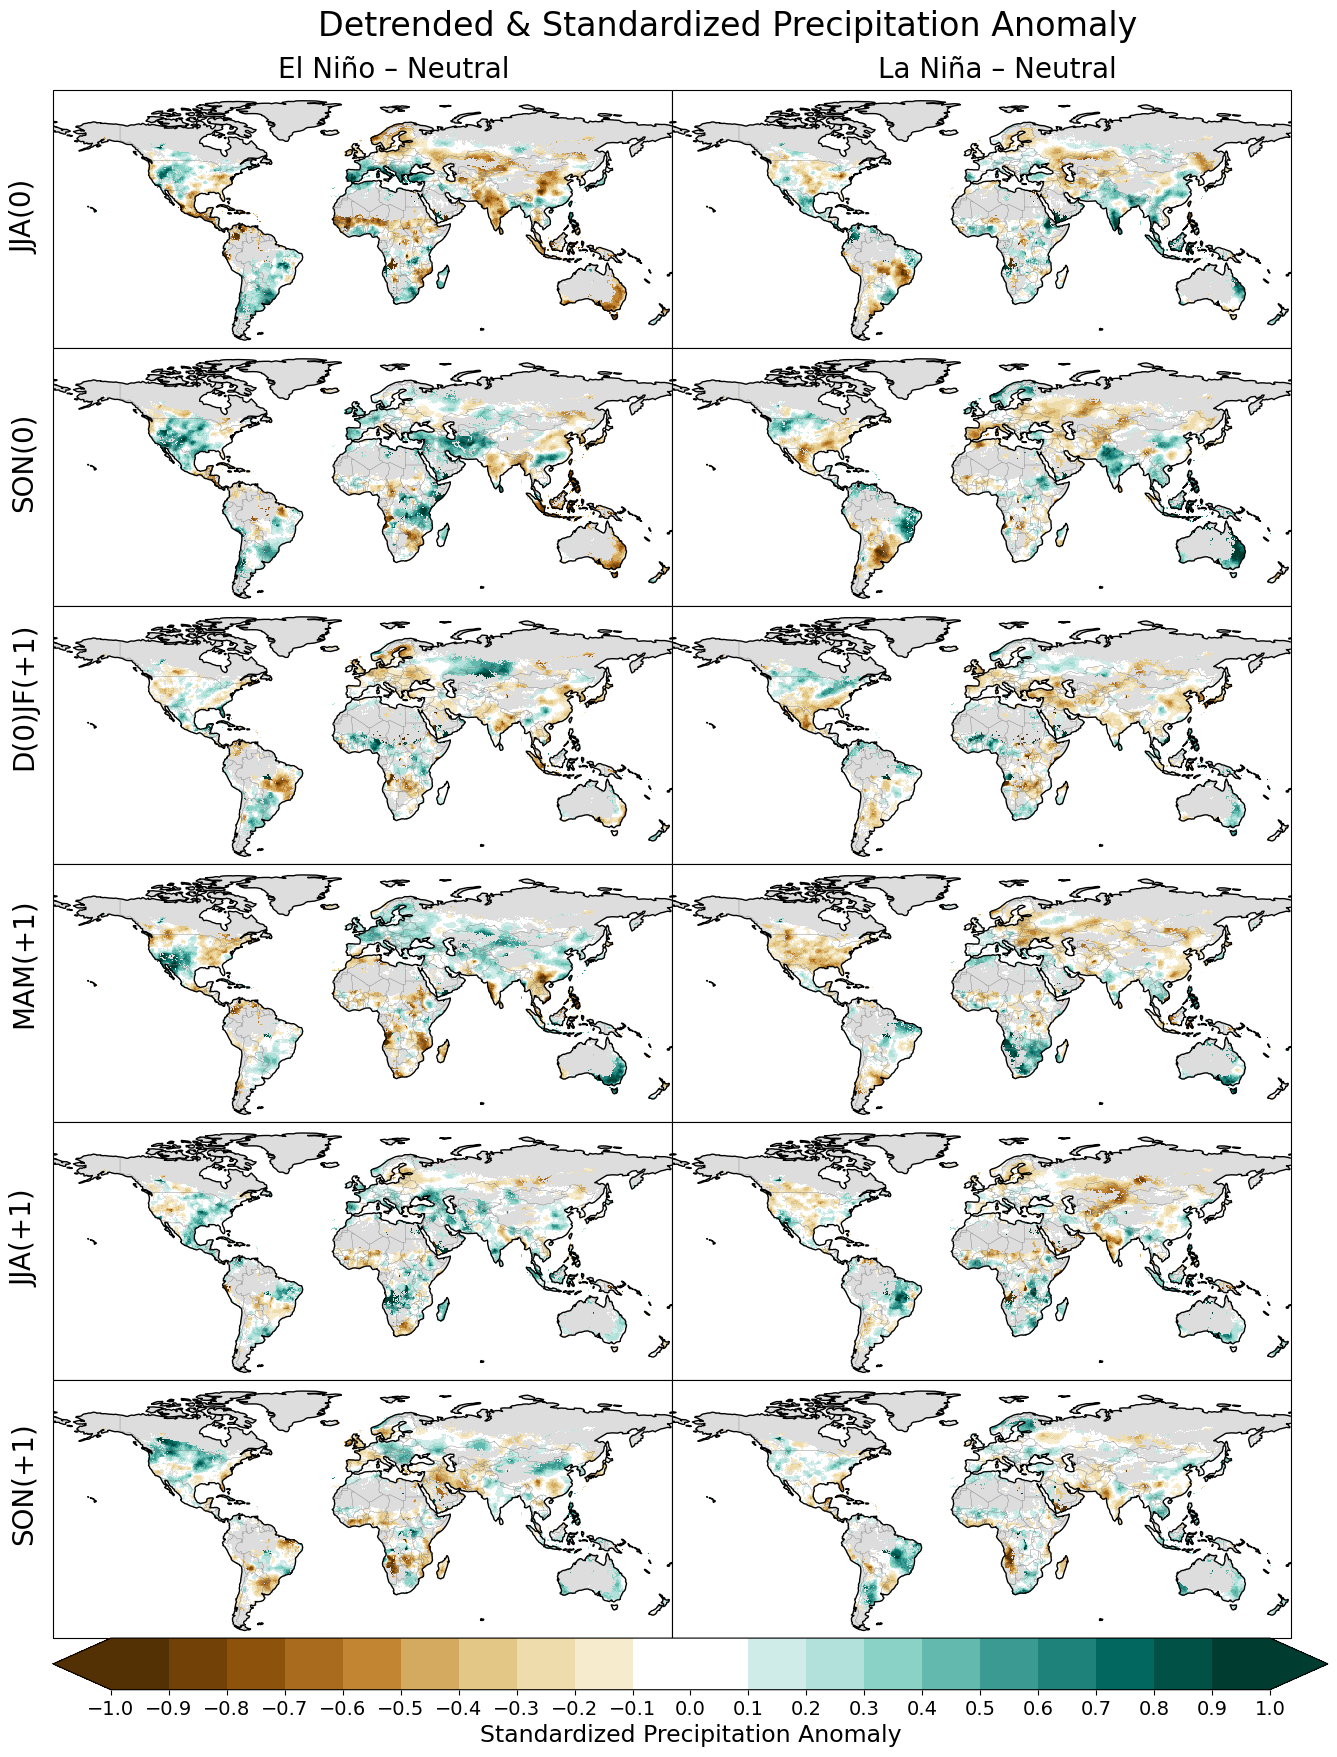

In [9]:
# your season names and titles
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# custom BrBG with white midpoint
brbg = plt.get_cmap('BrBG')(np.linspace(0,1,20))
brbg[9:11] = [1,1,1,1]  # force two central entries to white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', brbg, N=20)
levels = np.linspace(-1.0, 1.0, 21)

fig = plt.figure(figsize=(15,20))
gs =  fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# axes lists
axs_el = [fig.add_subplot(gs[i,0], projection=ccrs.PlateCarree()) for i in range(6)]
axs_la = [fig.add_subplot(gs[i,1], projection=ccrs.PlateCarree()) for i in range(6)]

# plot each season
for ax_el, ax_la, data_el, data_la, title in zip(
    axs_el,
    axs_la,
    pre_el_nino_minus_neutral_cropmask,
    pre_la_nina_minus_neutral_cropmask,
    titles
):
    # El Niño – Neutral
    im = ax_el.pcolormesh(
        data_el.lon, data_el.lat, data_el,
        cmap=cmap, vmin=-1.0, vmax=1.0,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_el.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_el.coastlines()
    ax_el.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_el.add_feature(cfeature.LAND, facecolor='#dddddd')
    ax_el.text(-205, -2, title, fontsize=20, ha='left', rotation='vertical')

    # La Niña – Neutral
    ax_la.pcolormesh(
        data_la.lon, data_la.lat, data_la,
        cmap=cmap, vmin=-1.0, vmax=1.0,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_la.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_la.coastlines()
    ax_la.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_la.add_feature(cfeature.LAND, facecolor='#dddddd')

# shared colorbar
cbar_ax = fig.add_subplot(gs[-1, :])  # Span all columns
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Standardized Precipitation Anomaly', extend='both')
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# super-title and column labels
fig.suptitle('Detrended & Standardized Precipitation Anomaly', fontsize=24, x=0.50, y=0.94)

fig.text(0.20, 0.91, 'El Niño – Neutral', fontsize=20, va='center')
fig.text(0.60, 0.91, 'La Niña – Neutral', fontsize=20, va='center')

# adjust margins
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)
plt.show()

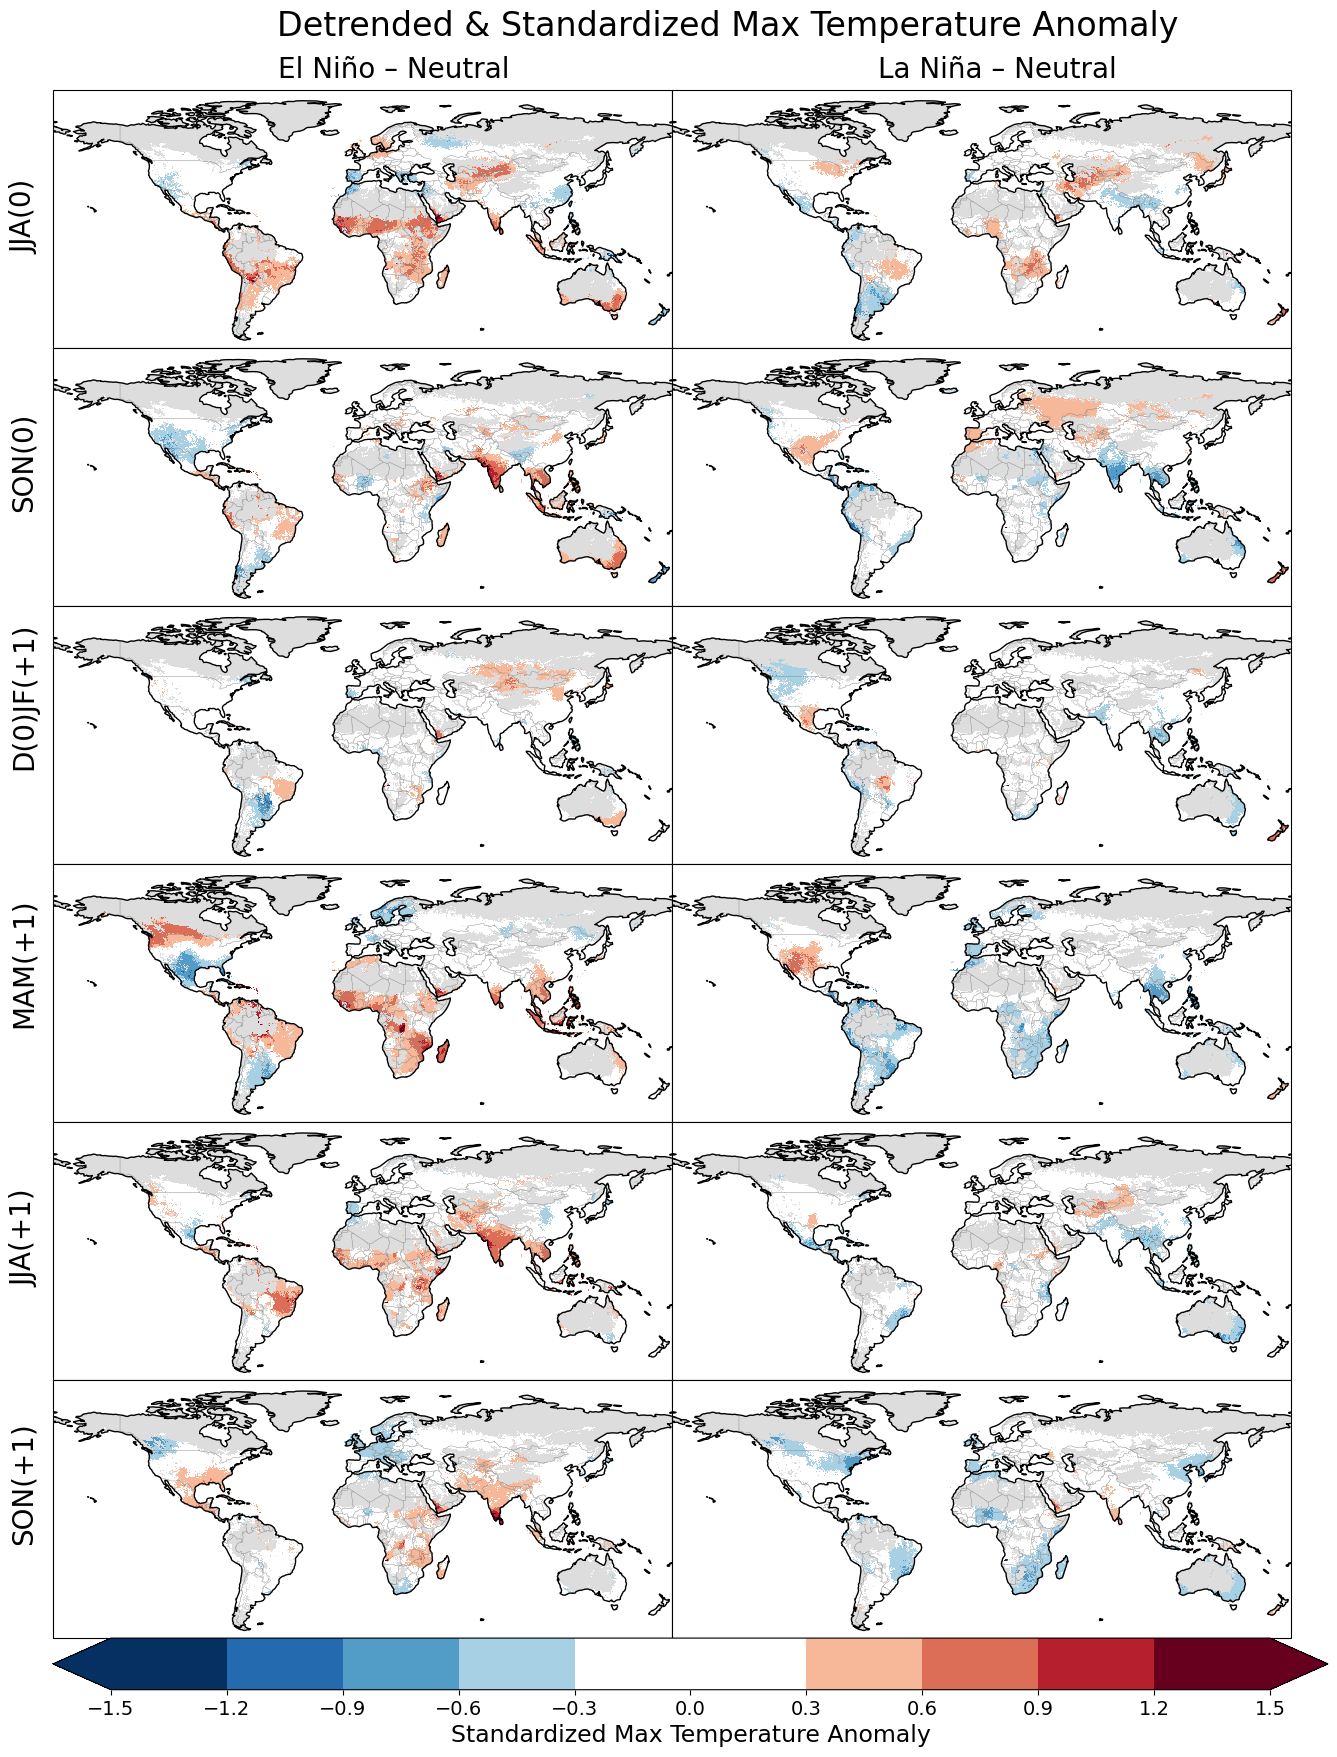

In [10]:
# your season names and titles
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# Sample colors from 'BrBG'
rdbu_rcolors = plt.get_cmap('RdBu_r')(np.linspace(0, 1, 10))
rdbu_rcolors[4] = [1, 1, 1, 1]  # Set the tenth color to white
rdbu_rcolors[5] = [1, 1, 1, 1]  # Set the tenth color to white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', rdbu_rcolors, N=10)
levels = np.linspace(-1.5, 1.5, 11)

fig = plt.figure(figsize=(15,20))
gs =  fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# axes lists
axs_el = [fig.add_subplot(gs[i,0], projection=ccrs.PlateCarree()) for i in range(6)]
axs_la = [fig.add_subplot(gs[i,1], projection=ccrs.PlateCarree()) for i in range(6)]

# plot each season
for ax_el, ax_la, data_el, data_la, title in zip(
    axs_el,
    axs_la,
    tmx_el_nino_minus_neutral_cropmask,
    tmx_la_nina_minus_neutral_cropmask,
    titles
):
    # El Niño – Neutral
    im = ax_el.pcolormesh(
        data_el.lon, data_el.lat, data_el,
        cmap=cmap, vmin=-1.5, vmax=1.5,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_el.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_el.coastlines()
    ax_el.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_el.add_feature(cfeature.LAND, facecolor='#dddddd')
    ax_el.text(-205, -2, title, fontsize=20, ha='left', rotation='vertical')

    # La Niña – Neutral
    ax_la.pcolormesh(
        data_la.lon, data_la.lat, data_la,
        cmap=cmap, vmin=-1.5, vmax=1.5,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_la.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_la.coastlines()
    ax_la.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_la.add_feature(cfeature.LAND, facecolor='#dddddd')

# shared colorbar
cbar_ax = fig.add_subplot(gs[-1, :])  # Span all columns
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Standardized Max Temperature Anomaly', extend='both')
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# super-title and column labels
fig.suptitle('Detrended & Standardized Max Temperature Anomaly', fontsize=24, x=0.50, y=0.94)

fig.text(0.20, 0.91, 'El Niño – Neutral', fontsize=20, va='center')
fig.text(0.60, 0.91, 'La Niña – Neutral', fontsize=20, va='center')

# adjust margins
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)
plt.show()

In [11]:
# std_tmx_anom_el[0][:,219,511]
# std_tmx_anom_ne[0][:,219,511]

In [12]:
# # Define bootstrap parameters
# n_bootstrap = 1000
# alpha = 0.1  # Significance threshold

# # Define the specific grid cell (Change these indices as needed)
# lat_idx, lon_idx = 219, 523  # Example grid cell indices

# # Extract data for the selected grid cell
# el_series = std_tmx_anom_el[0][:, lat_idx, lon_idx].values
# ne_series = std_tmx_anom_ne[0][:, lat_idx, lon_idx].values

# # Function to bootstrap and calculate p-value
# def bootstrap_p_value(series1, series2, n_bootstrap=1000):
#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
    
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []
    
#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)  # Shuffle combined data
#         sample1 = np.random.choice(combined, size=len(series1), replace=True)
#         sample2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))
    
#     # Compute p-value as the proportion of bootstrap samples greater than observed
#     p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
#     return p_value

# # Check if the grid cell has valid (non-NaN) values
# if not (np.isnan(el_series).all() or np.isnan(ne_series).all()):
#     # Compute bootstrap p-value
#     p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap)

#     # Determine significance
#     is_significant = p_val < alpha

#     # Print results
#     print(f"Bootstrap P-value: {p_val:.5f}")
#     print(f"Significant Difference (p < {alpha}): {is_significant}")
# else:
#     print("Grid cell contains only NaN values, skipping bootstrap test.")

In [13]:
# def bootstrap_p_value(series1, series2, n_bootstrap=1000):
#     # 1) drop NaNs
#     s1 = series1[~np.isnan(series1)]
#     s2 = series2[~np.isnan(series2)]

#     # 2) if either has no data, bail out
#     if len(s1) == 0 or len(s2) == 0:
#         return np.nan

#     # 3) observed difference
#     obs_diff = np.mean(s1) - np.mean(s2)

#     # 4) pooled bootstrap
#     combined = np.concatenate([s1, s2])
#     boot_diffs = np.empty(n_bootstrap)
#     for b in range(n_bootstrap):
#         # sample with replacement
#         b1 = np.random.choice(combined, size=len(s1), replace=True)
#         b2 = np.random.choice(combined, size=len(s2), replace=True)
#         boot_diffs[b] = np.mean(b1) - np.mean(b2)

#     # 5) two-tailed p-value
#     return np.mean(np.abs(boot_diffs) >= np.abs(obs_diff))


In [14]:
# # 1) Grab your two JJA slices
# el_cube = std_tmx_anom_el[0]   # dims like ('year','lat','lon')?
# ne_cube = std_tmx_anom_ne[0]

# # 2) Figure out your latitude & longitude coord names
# coords = list(el_cube.coords)
# # remove the 'year' coord to get the two spatial names
# spatial = [c for c in coords if c not in el_cube.dims[0:1]]
# lat_name, lon_name = spatial

# # 3) Extract the coordinate values
# lat_vals = el_cube[lat_name].values
# lon_vals = el_cube[lon_name].values

# # 4) Prepare mask array
# signif_mask = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)

# # 5) Loop over all grid cells
# for i in range(len(lat_vals)):
#     for j in range(len(lon_vals)):
#         s_el = el_cube[:, i, j].values
#         s_ne = ne_cube[:, i, j].values
#         if np.isnan(s_el).all() or np.isnan(s_ne).all():
#             continue
#         p_val = bootstrap_p_value(s_el, s_ne, n_bootstrap=1000)
#         if np.isnan(p_val):
#             continue    # not enough data here
#         signif_mask[i,j] = (p_val < alpha)


# # 6) Wrap into xarray
# signif_std_anom = xr.DataArray(
#     signif_mask,
#     coords={lat_name: lat_vals, lon_name: lon_vals},
#     dims=(lat_name, lon_name),
#     name='std_tmx_anom_significant'
# )

# signif_std_anom

In [15]:
# # import numpy as np
# # import matplotlib.pyplot as plt
# # import cartopy.crs as ccrs, cartopy.feature as cfeature

# # your JJA=0 slice
# data_el = tmx_el_nino_minus_neutral_cropmask[0]
# mask    = signif_std_anom.values  # 2D boolean

# # build figure
# fig = plt.figure(figsize=(10,5))
# ax  = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())

# # 1) base map
# im = ax.pcolormesh(
#     data_el.lon, data_el.lat, data_el,
#     cmap=cmap, vmin=-1.5, vmax=1.5,
#     transform=ccrs.PlateCarree(), shading='auto'
# )

# # 2) stipple via contourf‐hatch
# #    this draws the hatch only where mask==True

# ax.contourf(
#     data_el.lon, data_el.lat,
#     mask.astype(int),             # 0/1 array
#     levels=[0.5, 1.5],            # only fill the “1” region
#     hatches=['...'],              # your hatch pattern
#     colors='none',                # transparent fill
#     transform=ccrs.PlateCarree()
# )

# # 3) map decorations
# ax.set_extent([-182,180,-60,90], ccrs.PlateCarree())
# ax.coastlines()
# ax.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor='gray')
# ax.add_feature(cfeature.LAND,      facecolor='#dddddd')
# ax.text(-200, -2, 'JJA(0)', fontsize=20,
#         ha='left', va='center', rotation='vertical')
# ax.set_title('El Niño – Neutral', fontsize=18, pad=12)

# # 4) colorbar
# cbar = fig.colorbar(im, orientation='horizontal',
#                     pad=0.05, fraction=0.05, extend='both',
#                     ticks=np.linspace(-1.5,1.5,11))
# cbar.set_label('Standardized Max Temp Anomaly', fontsize=14)
# cbar.ax.tick_params(labelsize=12)

# plt.tight_layout()
# plt.show()

In [16]:
# # 1) Your bootstrap function (unchanged from before)
# def bootstrap_p_value(s1, s2, n_bootstrap=100):
#     # drop NaNs
#     s1 = s1[~np.isnan(s1)]
#     s2 = s2[~np.isnan(s2)]
#     if len(s1)==0 or len(s2)==0:
#         return np.nan
#     obs = s1.mean() - s2.mean()
#     combined = np.concatenate([s1, s2])
#     diffs = np.empty(n_bootstrap)
#     for b in range(n_bootstrap):
#         b1 = np.random.choice(combined, size=len(s1), replace=True)
#         b2 = np.random.choice(combined, size=len(s2), replace=True)
#         diffs[b] = b1.mean() - b2.mean()
#     return np.mean(np.abs(diffs) >= np.abs(obs))

# # 2) Get coordinate names and values
# #    assume std_tmx_anom_el and std_tmx_anom_ne are lists or arrays indexed by season 0–5
# sample = std_tmx_anom_el[0]
# # find your spatial coord names automatically
# dims = list(sample.dims)            # e.g. ['year','lat','lon']
# year_dim = dims[0]
# spatial = dims[1:]                  # ['lat','lon'] or similar
# lat_name, lon_name = spatial

# lat_vals = sample[lat_name].values
# lon_vals = sample[lon_name].values

# # 3) Prepare output mask: seasons × lat × lon
# n_seasons = len(std_tmx_anom_el)    # should be 6
# sig_mask = np.zeros((n_seasons, len(lat_vals), len(lon_vals)), dtype=bool)

# # 4) Loop over all seasons and grid cells
# for s in range(n_seasons):
#     el_cube = std_tmx_anom_el[s]   # shape (year, lat, lon)
#     ne_cube = std_tmx_anom_ne[s]
#     for i in range(len(lat_vals)):
#         for j in range(len(lon_vals)):
#             series_el = el_cube[:, i, j].values
#             series_ne = ne_cube[:, i, j].values
#             # skip if entirely NaN
#             if np.isnan(series_el).all() or np.isnan(series_ne).all():
#                 continue
#             p = bootstrap_p_value(series_el, series_ne, n_bootstrap=100)
#             if np.isnan(p):
#                 continue
#             sig_mask[s, i, j] = (p < 0.1)

# # 5) Wrap into a 3D DataArray with season labels
# season_labels = ['jja','son','djf','mam1','jja1','son1']
# signif_std_tmx_anom_el_ne = xr.DataArray(
#     sig_mask,
#     coords={
#       'season':     season_labels,
#       lat_name:     lat_vals,
#       lon_name:     lon_vals
#     },
#     dims=['season', lat_name, lon_name],
#     name='std_tmx_anom_significant'
# )

# # 6) Check
# signif_std_tmx_anom_el_ne
# # You can now do:
# # signif_std_tmx_anom_el_ne.sel(season='jja').plot()    # for JJA
# # or even facet‐grid over season:
# # signif_std_tmx_anom_el_ne.plot(col='season', col_wrap=3)

In [17]:
# # 2) Get coordinate names and values
# #    assume std_tmx_anom_el and std_tmx_anom_ne are lists or arrays indexed by season 0–5
# sample = std_tmx_anom_la[0]
# # find your spatial coord names automatically
# dims = list(sample.dims)            # e.g. ['year','lat','lon']
# year_dim = dims[0]
# spatial = dims[1:]                  # ['lat','lon'] or similar
# lat_name, lon_name = spatial

# lat_vals = sample[lat_name].values
# lon_vals = sample[lon_name].values

# # 3) Prepare output mask: seasons × lat × lon
# n_seasons = len(std_tmx_anom_la)    # should be 6
# sig_mask = np.zeros((n_seasons, len(lat_vals), len(lon_vals)), dtype=bool)

# # 4) Loop over all seasons and grid cells
# for s in range(n_seasons):
#     la_cube = std_tmx_anom_la[s]   # shape (year, lat, lon)
#     ne_cube = std_tmx_anom_ne[s]
#     for i in range(len(lat_vals)):
#         for j in range(len(lon_vals)):
#             series_la = la_cube[:, i, j].values
#             series_ne = ne_cube[:, i, j].values
#             # skip if entirely NaN
#             if np.isnan(series_la).all() or np.isnan(series_ne).all():
#                 continue
#             p = bootstrap_p_value(series_la, series_ne, n_bootstrap=100)
#             if np.isnan(p):
#                 continue
#             sig_mask[s, i, j] = (p < 0.1)

# # 5) Wrap into a 3D DataArray with season labels
# season_labels = ['jja','son','djf','mam1','jja1','son1']
# signif_std_tmx_anom_la_ne = xr.DataArray(
#     sig_mask,
#     coords={
#       'season':     season_labels,
#       lat_name:     lat_vals,
#       lon_name:     lon_vals
#     },
#     dims=['season', lat_name, lon_name],
#     name='std_tmx_anom_significant'
# )

# # 6) Check
# signif_std_tmx_anom_la_ne
# # You can now do:
# # signif_std_tmx_anom_la_ne.sel(season='jja').plot()    # for JJA
# # or even facet‐grid over season:
# # signif_std_tmx_anom_la_ne.plot(col='season', col_wrap=3)

In [18]:
# with open("/home/madhulika.gurazada/paper2/Data/signif_std_tmx_anom_el_ne.pkl","wb") as f:
#     pickle.dump(signif_std_tmx_anom_el_ne, f)
# with open("/home/madhulika.gurazada/paper2/Data/signif_std_tmx_anom_la_ne.pkl","wb") as f:
#     pickle.dump(signif_std_tmx_anom_la_ne, f)

In [19]:
file_el = "/home/madhulika.gurazada/paper2/Data/signif_std_tmx_anom_el_ne.pkl"
file_la = "/home/madhulika.gurazada/paper2/Data/signif_std_tmx_anom_la_ne.pkl"

with open(file_el, "rb") as f_el, open(file_la, "rb") as f_la:
    signif_std_tmx_anom_el_ne = pickle.load(f_el)
    signif_std_tmx_anom_la_ne = pickle.load(f_la)

In [20]:
signif_std_tmx_anom_el_ne_cropmask = [
    da.where(crop_mask)
    for da in signif_std_tmx_anom_el_ne
]

signif_std_tmx_anom_la_ne_cropmask = [
    da.where(crop_mask)
    for da in signif_std_tmx_anom_la_ne
]

In [21]:
# with open("/home/madhulika.gurazada/paper2/Data/signif_std_tmx_anom_el_ne_cropmask.pkl","wb") as f:
#     pickle.dump(signif_std_tmx_anom_el_ne_cropmask, f)
# with open("/home/madhulika.gurazada/paper2/Data/signif_std_tmx_anom_la_ne_cropmask.pkl","wb") as f:
#     pickle.dump(signif_std_tmx_anom_la_ne_cropmask, f)

In [22]:
file_el = "/home/madhulika.gurazada/paper2/Data/signif_std_tmx_anom_el_ne_cropmask.pkl"
file_la = "/home/madhulika.gurazada/paper2/Data/signif_std_tmx_anom_la_ne_cropmask.pkl"

with open(file_el, "rb") as f_el, open(file_la, "rb") as f_la:
    signif_std_tmx_anom_el_ne_cropmask = pickle.load(f_el)
    signif_std_tmx_anom_la_ne_cropmask = pickle.load(f_la)

In [23]:
season_labels = ['jja','son','djf','mam1','jja1', 'son1']

signif_std_tmx_anom_el_ne_cropmask = xr.concat(
    signif_std_tmx_anom_el_ne_cropmask,
    dim=pd.Index(season_labels, name='season')
)
signif_std_tmx_anom_la_ne_cropmask = xr.concat(
    signif_std_tmx_anom_la_ne_cropmask,
    dim=pd.Index(season_labels, name='season')
)

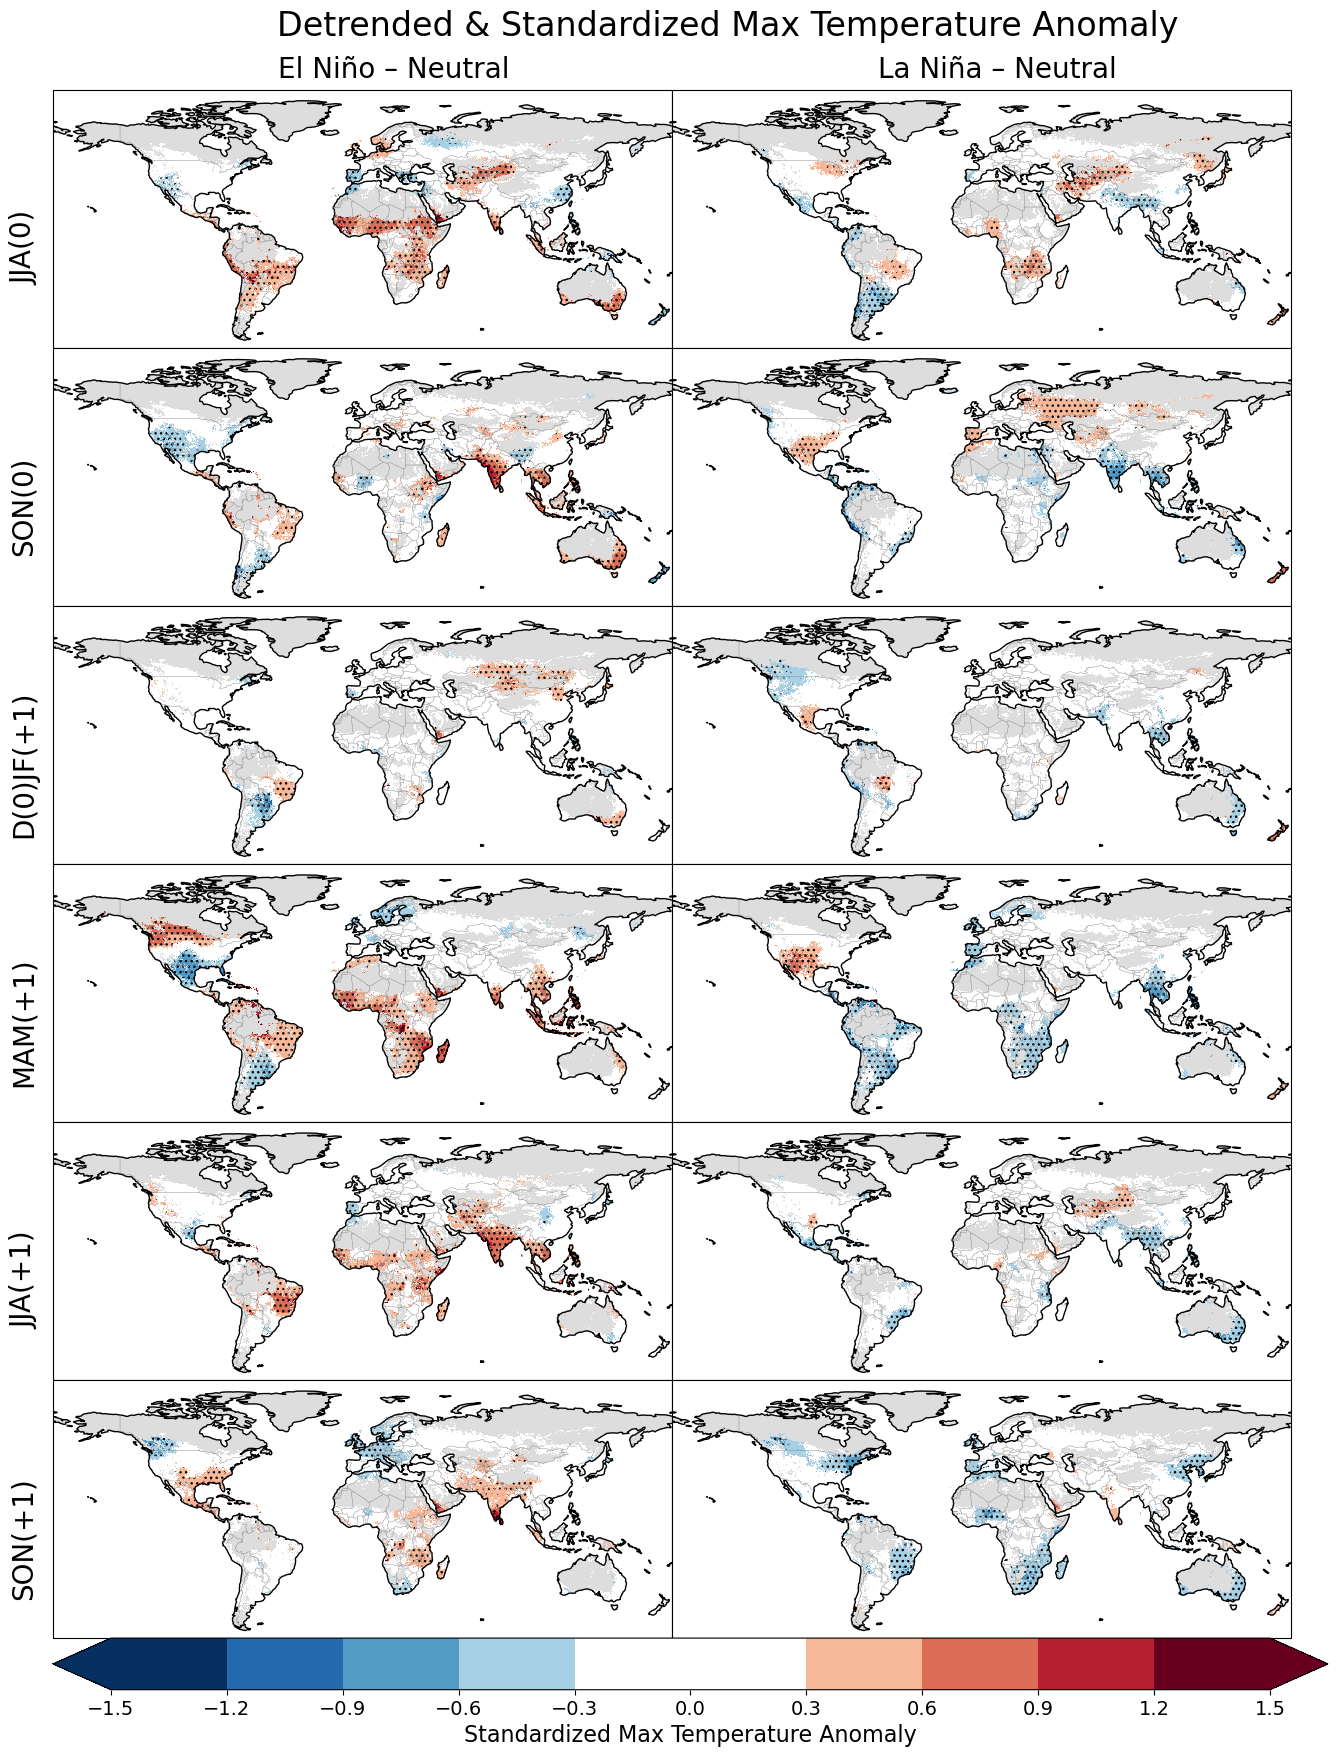

In [24]:
# ── 0) Season labels & titles ──────────────────────────────────────────────
season_labels = ['jja','son','djf','mam1','jja1','son1']
titles        = ['JJA(0)','SON(0)','D(0)JF(+1)','MAM(+1)','JJA(+1)','SON(+1)']

# ── 1) Build your custom colormap ─────────────────────────────────────────
rdbu = plt.get_cmap('RdBu_r')(np.linspace(0, 1, 10))
rdbu[4:6] = 1.0   # middle bins → white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', rdbu, N=10)
vmin, vmax = -1.5, 1.5


# ── 3) Set up figure & GridSpec ────────────────────────────────────────────
fig = plt.figure(figsize=(15,20))
gs  = fig.add_gridspec(
    7, 3,
    height_ratios=[5]*6 + [1],
    width_ratios =[1,1,0.06],
    wspace=0, hspace=0
)

# ── 4) Create one Cartopy axis per season×phase ───────────────────────────
axs_el = [fig.add_subplot(gs[i,0], projection=ccrs.PlateCarree()) for i in range(6)]
axs_la = [fig.add_subplot(gs[i,1], projection=ccrs.PlateCarree()) for i in range(6)]

# ── 5) Loop over seasons and plot ──────────────────────────────────────────
for idx, title in enumerate(titles):
    # raw anomaly DataArrays for this season
    da_el = tmx_el_nino_minus_neutral[idx]
    da_la = tmx_la_nina_minus_neutral[idx]

    # apply cropland mask to anomaly
    da_el_crop = da_el.where(crop_mask)
    da_la_crop = da_la.where(crop_mask)

    # seasonal significance masks (bool) → combine with crop mask
    sig_el = signif_std_tmx_anom_el_ne.sel(season=season_labels[idx])
    sig_la = signif_std_tmx_anom_la_ne.sel(season=season_labels[idx])

    mask_el = (sig_el & crop_mask).fillna(False).astype(int)
    mask_la = (sig_la & crop_mask).fillna(False).astype(int)

    ax_el = axs_el[idx]
    ax_la = axs_la[idx]

    # — El Niño – Neutral panel —
    im = ax_el.pcolormesh(
        da_el_crop.lon, da_el_crop.lat, da_el_crop,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_el.contourf(
        da_el_crop.lon, da_el_crop.lat, mask_el.values,
        levels=[0.5,1.5],
        hatches=['...'],
        colors='none',
        transform=ccrs.PlateCarree()
    )
    ax_el.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_el.coastlines()
    ax_el.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_el.add_feature(cfeature.LAND,    facecolor='#dddddd')
    ax_el.text(-205, -2, title, fontsize=20,
               ha='left', va='center', rotation='vertical')

    # — La Niña – Neutral panel —
    ax_la.pcolormesh(
        da_la_crop.lon, da_la_crop.lat, da_la_crop,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_la.contourf(
        da_la_crop.lon, da_la_crop.lat, mask_la.values,
        levels=[0.5,1.5],
        hatches=['...'],
        colors='none',
        transform=ccrs.PlateCarree()
    )
    ax_la.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_la.coastlines()
    ax_la.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_la.add_feature(cfeature.LAND,    facecolor='#dddddd')

# ── 6) Shared colorbar ──────────────────────────────────────────────────────
cbar_ax = fig.add_subplot(gs[-1, :])
cbar = plt.colorbar(
    im, cax=cbar_ax, orientation='horizontal',
    ticks=np.linspace(vmin, vmax, 11),
    extend='both'
)
cbar.set_label('Standardized Max Temperature Anomaly', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# ── 7) Titles & annotations ─────────────────────────────────────────────────
fig.suptitle('Detrended & Standardized Max Temperature Anomaly', fontsize=24, y=0.94)
fig.text(0.20, 0.91, 'El Niño – Neutral', fontsize=20, va='center')
fig.text(0.60, 0.91, 'La Niña – Neutral', fontsize=20, va='center')

# ── 8) Final layout ─────────────────────────────────────────────────────────
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)
plt.show()

In [25]:
# # 2) Get coordinate names and values
# #    assume std_pre_anom_el and std_pre_anom_ne are lists or arrays indexed by season 0–5
# sample = std_pre_anom_el[0]
# # find your spatial coord names automatically
# dims = list(sample.dims)            # e.g. ['year','lat','lon']
# year_dim = dims[0]
# spatial = dims[1:]                  # ['lat','lon'] or similar
# lat_name, lon_name = spatial

# lat_vals = sample[lat_name].values
# lon_vals = sample[lon_name].values

# # 3) Prepare output mask: seasons × lat × lon
# n_seasons = len(std_pre_anom_el)    # should be 6
# sig_mask = np.zeros((n_seasons, len(lat_vals), len(lon_vals)), dtype=bool)

# # 4) Loop over all seasons and grid cells
# for s in range(n_seasons):
#     el_cube = std_pre_anom_el[s]   # shape (year, lat, lon)
#     ne_cube = std_pre_anom_ne[s]
#     for i in range(len(lat_vals)):
#         for j in range(len(lon_vals)):
#             series_el = el_cube[:, i, j].values
#             series_ne = ne_cube[:, i, j].values
#             # skip if entirely NaN
#             if np.isnan(series_el).all() or np.isnan(series_ne).all():
#                 continue
#             p = bootstrap_p_value(series_el, series_ne, n_bootstrap=100)
#             if np.isnan(p):
#                 continue
#             sig_mask[s, i, j] = (p < 0.1)

# # 5) Wrap into a 3D DataArray with season labels
# season_labels = ['jja','son','djf','mam1','jja1','son1']
# signif_std_pre_anom_el_ne = xr.DataArray(
#     sig_mask,
#     coords={
#       'season':     season_labels,
#       lat_name:     lat_vals,
#       lon_name:     lon_vals
#     },
#     dims=['season', lat_name, lon_name],
#     name='std_pre_anom_significant'
# )

# # 6) Check
# signif_std_pre_anom_el_ne
# # You can now do:
# # signif_std_pre_anom_el_ne.sel(season='jja').plot()    # for JJA
# # or even facet‐grid over season:
# # signif_std_pre_anom_el_ne.plot(col='season', col_wrap=3)

In [26]:
# # 2) Get coordinate names and values
# #    assume std_pre_anom_el and std_pre_anom_ne are lists or arrays indexed by season 0–5
# sample = std_pre_anom_la[0]
# # find your spatial coord names automatically
# dims = list(sample.dims)            # e.g. ['year','lat','lon']
# year_dim = dims[0]
# spatial = dims[1:]                  # ['lat','lon'] or similar
# lat_name, lon_name = spatial

# lat_vals = sample[lat_name].values
# lon_vals = sample[lon_name].values

# # 3) Prepare output mask: seasons × lat × lon
# n_seasons = len(std_pre_anom_la)    # should be 6
# sig_mask = np.zeros((n_seasons, len(lat_vals), len(lon_vals)), dtype=bool)

# # 4) Loop over all seasons and grid cells
# for s in range(n_seasons):
#     la_cube = std_pre_anom_la[s]   # shape (year, lat, lon)
#     ne_cube = std_pre_anom_ne[s]
#     for i in range(len(lat_vals)):
#         for j in range(len(lon_vals)):
#             series_la = la_cube[:, i, j].values
#             series_ne = ne_cube[:, i, j].values
#             # skip if entirely NaN
#             if np.isnan(series_la).all() or np.isnan(series_ne).all():
#                 continue
#             p = bootstrap_p_value(series_la, series_ne, n_bootstrap=100)
#             if np.isnan(p):
#                 continue
#             sig_mask[s, i, j] = (p < 0.1)

# # 5) Wrap into a 3D DataArray with season labels
# season_labels = ['jja','son','djf','mam1','jja1','son1']
# signif_std_pre_anom_la_ne = xr.DataArray(
#     sig_mask,
#     coords={
#       'season':     season_labels,
#       lat_name:     lat_vals,
#       lon_name:     lon_vals
#     },
#     dims=['season', lat_name, lon_name],
#     name='std_pre_anom_significant'
# )

# # 6) Check
# signif_std_pre_anom_la_ne
# # You can now do:
# # signif_std_pre_anom_la_ne.sel(season='jja').plot()    # for JJA
# # or even facet‐grid over season:
# # signif_std_pre_anom_la_ne.plot(col='season', col_wrap=3)

In [27]:
# with open("/home/madhulika.gurazada/paper2/Data/signif_std_pre_anom_el_ne.pkl","wb") as f:
#     pickle.dump(signif_std_pre_anom_el_ne, f)
# with open("/home/madhulika.gurazada/paper2/Data/signif_std_pre_anom_la_ne.pkl","wb") as f:
#     pickle.dump(signif_std_pre_anom_la_ne, f)

In [28]:
file_el = "/home/madhulika.gurazada/paper2/Data/signif_std_pre_anom_el_ne.pkl"
file_la = "/home/madhulika.gurazada/paper2/Data/signif_std_pre_anom_la_ne.pkl"

with open(file_el, "rb") as f_el, open(file_la, "rb") as f_la:
    signif_std_pre_anom_el_ne = pickle.load(f_el)
    signif_std_pre_anom_la_ne = pickle.load(f_la)

In [29]:
signif_std_pre_anom_el_ne_cropmask = [
    da.where(crop_mask)
    for da in signif_std_pre_anom_el_ne
]

signif_std_pre_anom_la_ne_cropmask = [
    da.where(crop_mask)
    for da in signif_std_pre_anom_la_ne
]

In [30]:
# with open("/home/madhulika.gurazada/paper2/Data/signif_std_pre_anom_el_ne_cropmask.pkl","wb") as f:
#     pickle.dump(signif_std_pre_anom_el_ne_cropmask, f)
# with open("/home/madhulika.gurazada/paper2/Data/signif_std_pre_anom_la_ne_cropmask.pkl","wb") as f:
#     pickle.dump(signif_std_pre_anom_la_ne_cropmask, f)

In [31]:
# reload:
with open("/home/madhulika.gurazada/paper2/Data/signif_std_pre_anom_el_ne_cropmask.pkl","rb") as f:
    signif_std_pre_anom_el_ne_cropmask = pickle.load(f)
    
with open("/home/madhulika.gurazada/paper2/Data/signif_std_pre_anom_la_ne_cropmask.pkl","rb") as f:
    signif_std_pre_anom_el_ne_cropmask = pickle.load(f)


In [32]:
signif_std_pre_anom_el_ne_cropmask = xr.concat(
    signif_std_pre_anom_el_ne_cropmask,
    dim=pd.Index(season_labels, name='season')
)
signif_std_pre_anom_la_ne_cropmask = xr.concat(
    signif_std_pre_anom_la_ne_cropmask,
    dim=pd.Index(season_labels, name='season')
)

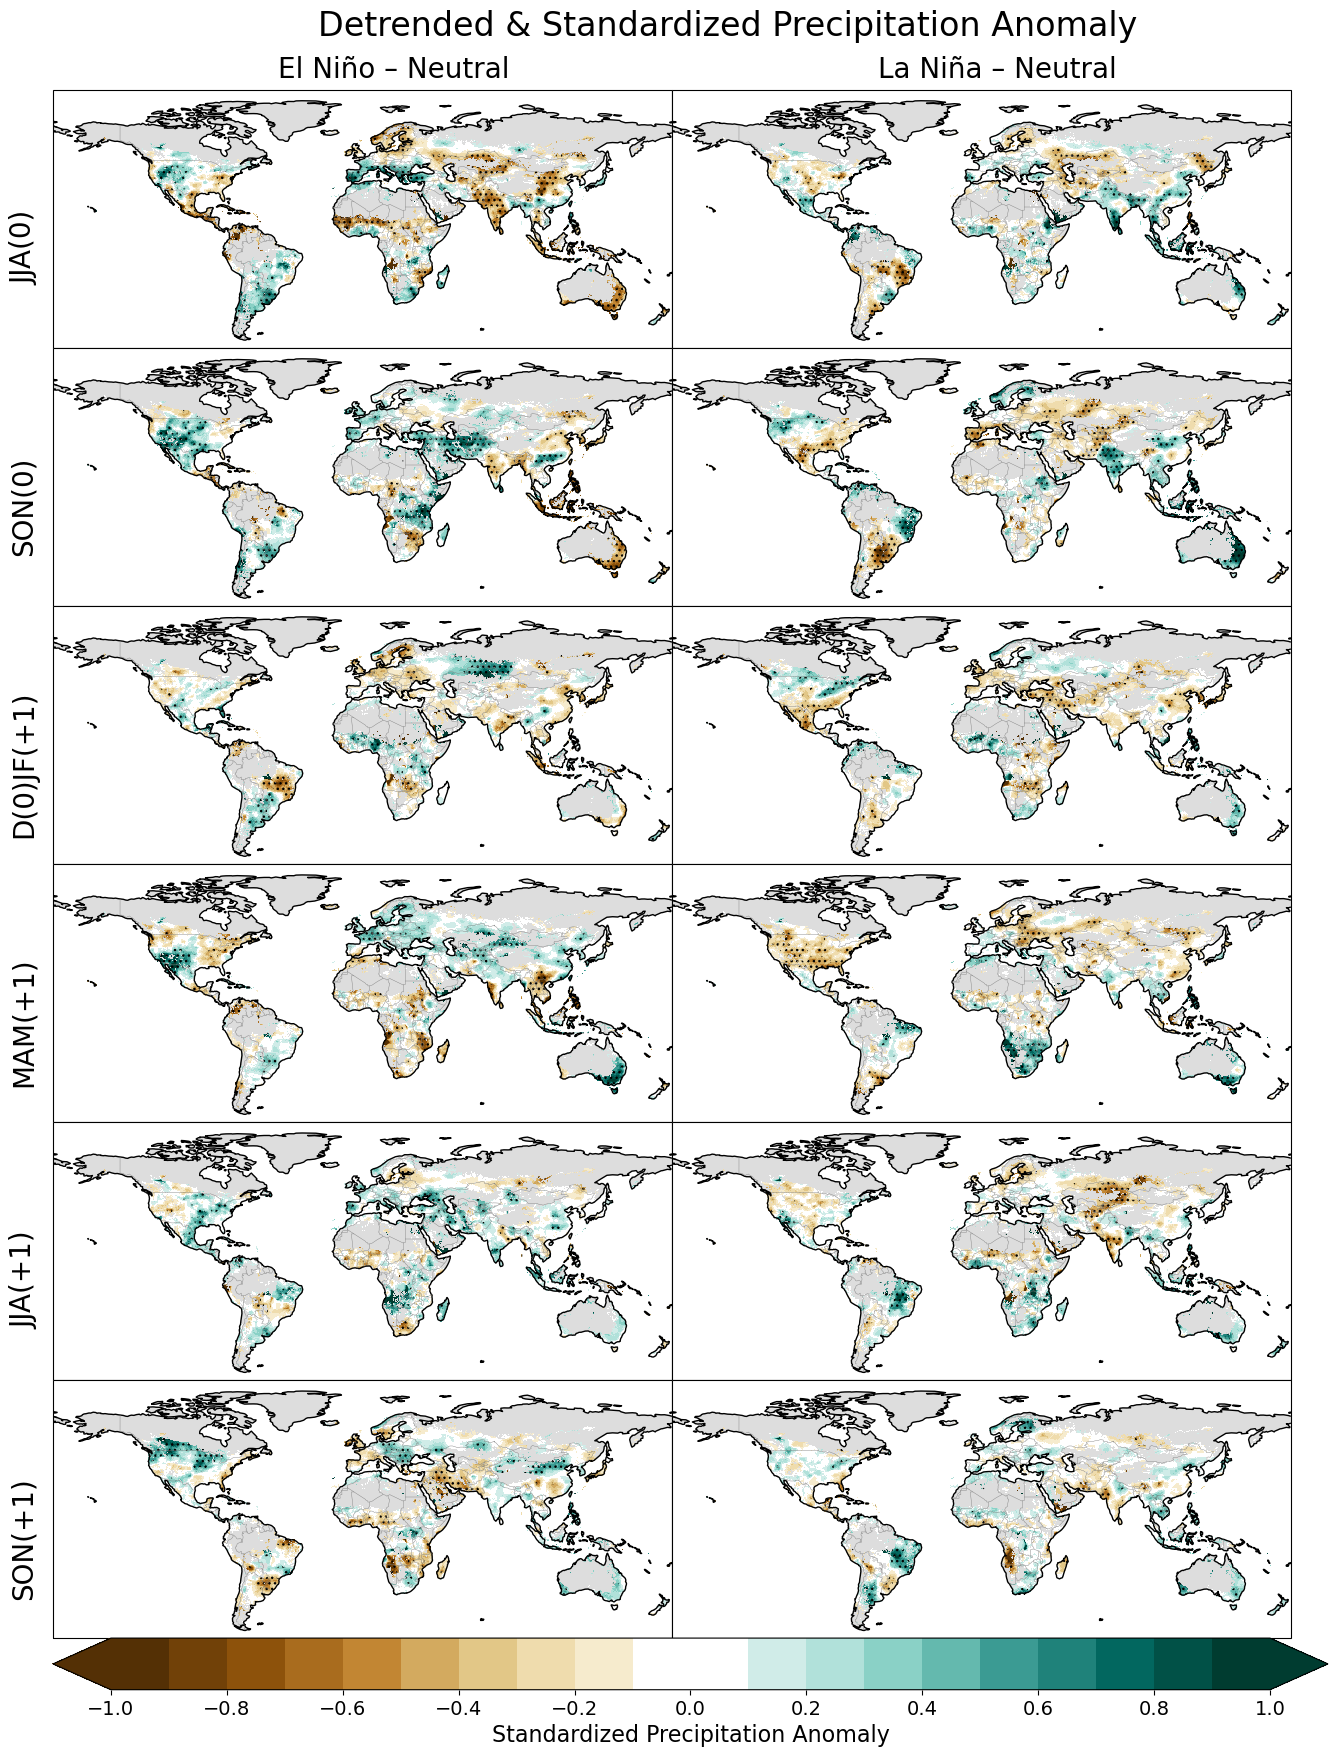

In [33]:
# ── 0) Season labels & titles ──────────────────────────────────────────────
season_labels = ['jja','son','djf','mam1','jja1','son1']
titles        = ['JJA(0)','SON(0)','D(0)JF(+1)','MAM(+1)','JJA(+1)','SON(+1)']

# ── 1) Build your custom colormap ─────────────────────────────────────────
brbg = plt.get_cmap('BrBG')(np.linspace(0,1,20))
brbg[9:11] = [1,1,1,1]  # force two central entries to white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', brbg, N=20)
vmin, vmax = -1, 1


# ── 3) Set up figure & GridSpec ────────────────────────────────────────────
fig = plt.figure(figsize=(15,20))
gs  = fig.add_gridspec(
    7, 3,
    height_ratios=[5]*6 + [1],
    width_ratios =[1,1,0.06],
    wspace=0, hspace=0
)

# ── 4) Create one Cartopy axis per season×phase ───────────────────────────
axs_el = [fig.add_subplot(gs[i,0], projection=ccrs.PlateCarree()) for i in range(6)]
axs_la = [fig.add_subplot(gs[i,1], projection=ccrs.PlateCarree()) for i in range(6)]

# ── 5) Loop over seasons and plot ──────────────────────────────────────────
for idx, title in enumerate(titles):
    # raw anomaly DataArrays for this season
    da_el = pre_el_nino_minus_neutral[idx]
    da_la = pre_la_nina_minus_neutral[idx]

    # apply cropland mask to anomaly
    da_el_crop = da_el.where(crop_mask)
    da_la_crop = da_la.where(crop_mask)

    # seasonal significance masks (bool) → combine with crop mask
    sig_el = signif_std_pre_anom_el_ne.sel(season=season_labels[idx])
    sig_la = signif_std_pre_anom_la_ne.sel(season=season_labels[idx])

    mask_el = (sig_el & crop_mask).fillna(False).astype(int)
    mask_la = (sig_la & crop_mask).fillna(False).astype(int)

    ax_el = axs_el[idx]
    ax_la = axs_la[idx]

    # — El Niño – Neutral panel —
    im = ax_el.pcolormesh(
        da_el_crop.lon, da_el_crop.lat, da_el_crop,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_el.contourf(
        da_el_crop.lon, da_el_crop.lat, mask_el.values,
        levels=[0.5,1.5],
        hatches=['...'],
        colors='none',
        transform=ccrs.PlateCarree()
    )
    ax_el.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_el.coastlines()
    ax_el.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_el.add_feature(cfeature.LAND,    facecolor='#dddddd')
    ax_el.text(-205, -2, title, fontsize=20,
               ha='left', va='center', rotation='vertical')

    # — La Niña – Neutral panel —
    ax_la.pcolormesh(
        da_la_crop.lon, da_la_crop.lat, da_la_crop,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_la.contourf(
        da_la_crop.lon, da_la_crop.lat, mask_la.values,
        levels=[0.5,1.5],
        hatches=['...'],
        colors='none',
        transform=ccrs.PlateCarree()
    )
    ax_la.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_la.coastlines()
    ax_la.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_la.add_feature(cfeature.LAND,    facecolor='#dddddd')

# ── 6) Shared colorbar ──────────────────────────────────────────────────────
cbar_ax = fig.add_subplot(gs[-1, :])
cbar = plt.colorbar(
    im, cax=cbar_ax, orientation='horizontal',
    ticks=np.linspace(vmin, vmax, 11),
    extend='both'
)
cbar.set_label('Standardized Precipitation Anomaly', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# ── 7) Titles & annotations ─────────────────────────────────────────────────
fig.suptitle('Detrended & Standardized Precipitation Anomaly', fontsize=24, y=0.94)
fig.text(0.20, 0.91, 'El Niño – Neutral', fontsize=20, va='center')
fig.text(0.60, 0.91, 'La Niña – Neutral', fontsize=20, va='center')

# ── 8) Final layout ─────────────────────────────────────────────────────────
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)
plt.show()